# Adaptive Job-Application UI Selection — Final Report Pipeline

This notebook loads the **actual** experiment output from the 1.05M-round benchmark and
regenerates every figure and summary table used in the final report.

**Inputs (canonical):**
- `outputs/tables/experiment_results_full_online_none.parquet` (5.25M rows: 1.05M rounds × 5 algorithms)
- `outputs/tables/algo_summary.csv` (final per-algorithm summary)
- `outputs/tables/arm_selection_frequency.csv` (per-algorithm arm share)
- `outputs/tables/world_summary.csv` (world composition stats)

**Outputs:**
- Seven PNG figures in `outputs/figures/` (same filenames the report references)
- `outputs/figures/policy_summary_table.csv` (now computed from real data)

Every number in the report is traceable to one of the files this notebook reads.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "savefig.bbox": "tight",
})

NB_DIR = Path.cwd()
REPO = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
TABLES = REPO / "outputs" / "tables"
FIGS = REPO / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

PARQUET = TABLES / "experiment_results_full_online_none.parquet"
ALGO_CSV = TABLES / "algo_summary.csv"
ARM_CSV = TABLES / "arm_selection_frequency.csv"
WORLD_CSV = TABLES / "world_summary.csv"

for p in [PARQUET, ALGO_CSV, ARM_CSV, WORLD_CSV]:
    print(f"{'OK' if p.exists() else 'MISSING':7} {p.relative_to(REPO)}")

OK      outputs\tables\experiment_results_full_online_none.parquet
OK      outputs\tables\algo_summary.csv
OK      outputs\tables\arm_selection_frequency.csv
OK      outputs\tables\world_summary.csv


## 1. Load data

All figures below are computed from these files — no hardcoded constants.

In [2]:
df = pd.read_parquet(PARQUET)
algo_summary = pd.read_csv(ALGO_CSV)
arm_freq = pd.read_csv(ARM_CSV)
world_summary = pd.read_csv(WORLD_CSV)

print(f"experiment_results: {len(df):,} rows × {df.shape[1]} cols")
print(f"algorithms:         {sorted(df['algo_name'].unique())}")
print(f"arms:               {sorted(df['arm_selected_name'].unique())}")
print(f"session goals:      {sorted(df['session_goal'].unique())}")
print(f"outcomes:           {sorted(df['outcome'].unique())}")
print(f"rounds per algo:    {len(df) // df['algo_name'].nunique():,}")
print()
print("=== algo_summary.csv (canonical) ===")
print(algo_summary.to_string(index=False))

experiment_results: 5,250,000 rows × 21 cols
algorithms:         ['contextual_ts', 'epsilon_greedy', 'gaussian_ts', 'linucb', 'ucb1']
arms:               ['card_grid', 'guided_chat', 'hybrid_ranked', 'panel_split', 'swipe_fast']
session goals:      ['broad_exploration', 'casual_browse', 'focused_search', 'panic_apply']
outcomes:           ['ignored', 'interview_1', 'rejected']
rounds per algo:    1,050,000

=== algo_summary.csv (canonical) ===
     algo_name   mode  final_cumulative_reward  final_cumulative_expected_regret  mean_reward  interview_rate  ignore_rate
 contextual_ts online            151722.814605                      10302.826091     0.144498        0.138494     0.591791
        linucb online            151293.077745                      11028.819340     0.144089        0.138226     0.591774
   gaussian_ts online            143242.546418                      18854.904983     0.136421        0.133746     0.603024
epsilon_greedy online            144075.389520              

## 2. Display order and color palette

Ordering algorithms by final cumulative regret (best first) for consistent presentation.

In [3]:
ALGO_ORDER = (algo_summary
    .sort_values('final_cumulative_expected_regret')
    ['algo_name'].tolist())
print("Display order (low regret → high):", ALGO_ORDER)

ARM_ORDER = ['panel_split', 'card_grid', 'swipe_fast', 'guided_chat', 'hybrid_ranked']
SESSION_ORDER = ['focused_search', 'broad_exploration', 'panic_apply', 'casual_browse']

PALETTE = {
    'contextual_ts':  '#d62728',   # red
    'linucb':         '#ff7f0e',   # orange
    'gaussian_ts':    '#2ca02c',   # green
    'epsilon_greedy': '#1f77b4',   # blue
    'ucb1':           '#9467bd',   # purple
}
NICE_NAME = {
    'contextual_ts':  'Contextual TS',
    'linucb':         'LinUCB',
    'gaussian_ts':    'Gaussian TS',
    'epsilon_greedy': 'ε-Greedy',
    'ucb1':           'UCB1',
}

ARM_COLORS = {
    'panel_split':   '#1f77b4',
    'card_grid':     '#ff7f0e',
    'swipe_fast':    '#2ca02c',
    'guided_chat':   '#d62728',
    'hybrid_ranked': '#9467bd',
}

Display order (low regret → high): ['contextual_ts', 'linucb', 'gaussian_ts', 'epsilon_greedy', 'ucb1']


## 3. Final summary table (computed from real data)

Replaces the old `policy_summary_table.csv` that previously used hand-written numbers.

In [4]:
rows = []
for algo in ALGO_ORDER:
    rsum = algo_summary[algo_summary['algo_name'] == algo].iloc[0]
    rows.append({
        'policy': NICE_NAME[algo],
        'final_cum_reward': round(rsum['final_cumulative_reward'], 2),
        'final_cum_regret': round(rsum['final_cumulative_expected_regret'], 2),
        'mean_reward': round(rsum['mean_reward'], 4),
        'interview_rate': round(rsum['interview_rate'], 4),
        'ignore_rate': round(rsum['ignore_rate'], 4),
    })

policy_summary = pd.DataFrame(rows)
policy_summary.to_csv(FIGS / 'policy_summary_table.csv', index=False)
print(policy_summary.to_string(index=False))

       policy  final_cum_reward  final_cum_regret  mean_reward  interview_rate  ignore_rate
Contextual TS         151722.81          10302.83       0.1445          0.1385       0.5918
       LinUCB         151293.08          11028.82       0.1441          0.1382       0.5918
  Gaussian TS         143242.55          18854.90       0.1364          0.1337       0.6030
     ε-Greedy         144075.39          19447.20       0.1372          0.1343       0.6047
         UCB1         140855.37          22874.04       0.1341          0.1304       0.6136


## 4. Figure 1 — Simulator world stats

Session-goal distribution, company-tier distribution, applicant-cohort distribution,
and outcome mix by algorithm.

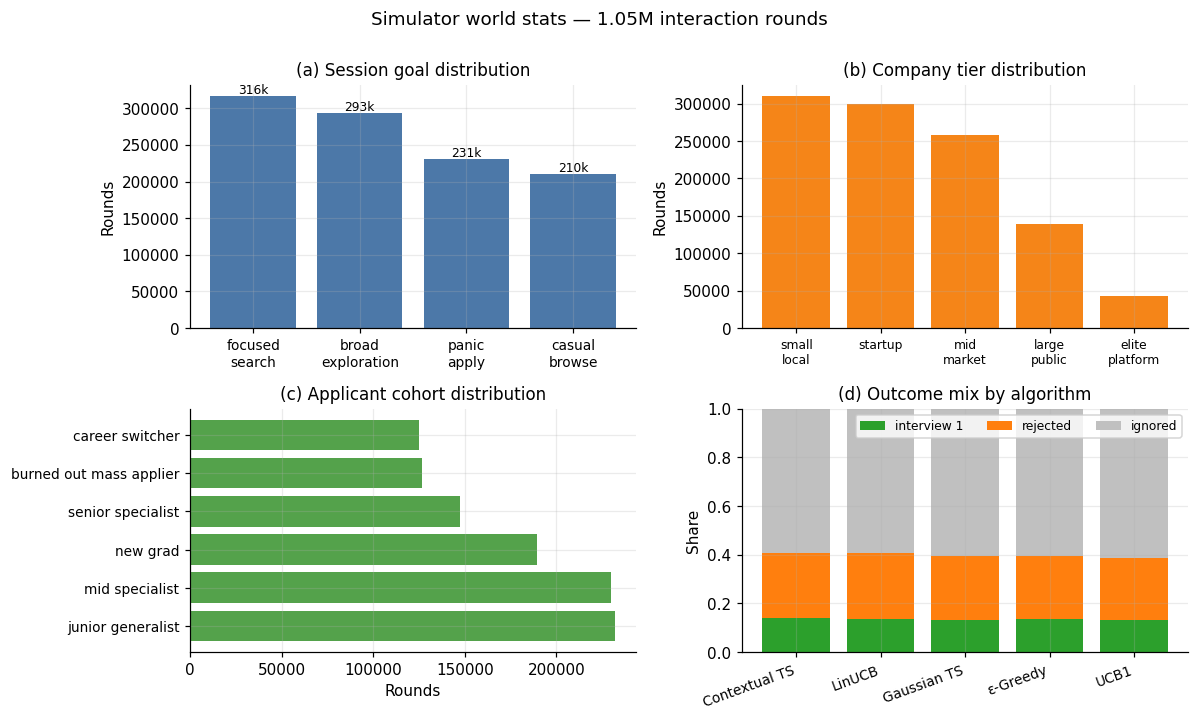

In [5]:
# One algorithm's view gives us the per-round features (they're identical across algos per round)
one_algo = df[df['algo_name'] == 'epsilon_greedy'].copy()

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))

# (a) Session goal distribution
ax = axes[0, 0]
sg = one_algo['session_goal'].value_counts().reindex(SESSION_ORDER)
ax.bar(range(len(sg)), sg.values, color='#4c78a8')
ax.set_xticks(range(len(sg)))
ax.set_xticklabels([s.replace('_', '\n') for s in sg.index], fontsize=9)
ax.set_ylabel('Rounds')
ax.set_title('(a) Session goal distribution')
for i, v in enumerate(sg.values):
    ax.text(i, v, f'{v/1000:.0f}k', ha='center', va='bottom', fontsize=8)

# (b) Company tier distribution
ax = axes[0, 1]
tier_order = ['small_local', 'startup', 'mid_market', 'large_public', 'elite_platform']
ct = one_algo['company_tier'].value_counts()
ct = ct.reindex([t for t in tier_order if t in ct.index])
ax.bar(range(len(ct)), ct.values, color='#f58518')
ax.set_xticks(range(len(ct)))
ax.set_xticklabels([s.replace('_', '\n') for s in ct.index], fontsize=8)
ax.set_ylabel('Rounds')
ax.set_title('(b) Company tier distribution')

# (c) Applicant cohort distribution
ax = axes[1, 0]
ac = one_algo['applicant_cohort'].value_counts()
ax.barh(range(len(ac)), ac.values, color='#54a24b')
ax.set_yticks(range(len(ac)))
ax.set_yticklabels([s.replace('_', ' ') for s in ac.index], fontsize=9)
ax.set_xlabel('Rounds')
ax.set_title('(c) Applicant cohort distribution')

# (d) Outcome mix by algorithm
ax = axes[1, 1]
outcome_counts = df.groupby(['algo_name', 'outcome']).size().unstack(fill_value=0)
outcome_shares = outcome_counts.div(outcome_counts.sum(axis=1), axis=0).reindex(ALGO_ORDER)
outcome_shares = outcome_shares[['interview_1', 'rejected', 'ignored']]
bottom = np.zeros(len(outcome_shares))
for col, color in zip(outcome_shares.columns, ['#2ca02c', '#ff7f0e', '#c0c0c0']):
    ax.bar(range(len(outcome_shares)), outcome_shares[col], bottom=bottom,
           label=col.replace('_', ' '), color=color)
    bottom += outcome_shares[col].values
ax.set_xticks(range(len(outcome_shares)))
ax.set_xticklabels([NICE_NAME[a] for a in outcome_shares.index],
                    rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Share')
ax.set_ylim(0, 1)
ax.set_title('(d) Outcome mix by algorithm')
ax.legend(loc='upper right', fontsize=8, ncol=3)

fig.suptitle('Simulator world stats — 1.05M interaction rounds', fontsize=12, y=1.00)
fig.tight_layout()
fig.savefig(FIGS / '01_simulator_world_stats.png')
plt.show()

## 5. Figure 2 — Reward landscape (oracle best arm per session goal)

Left: how often each arm is the oracle-best choice in each session-goal context (%).
Right: the mean oracle expected reward realized in each (session-goal, arm) cell.

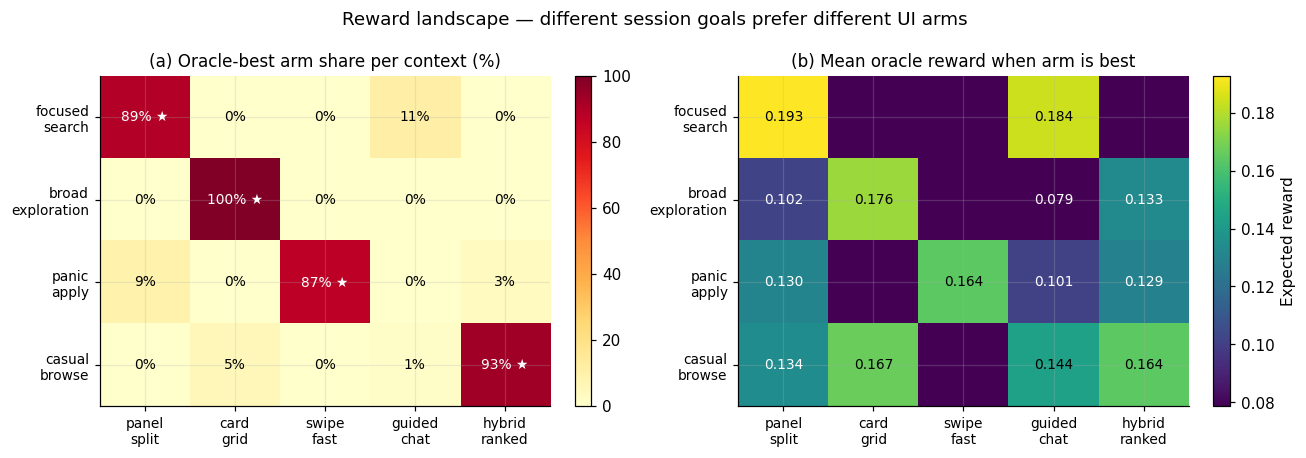


Oracle-best shares (%) by session goal:
oracle_arm_name    panel_split  card_grid  swipe_fast  guided_chat  hybrid_ranked
session_goal                                                                     
focused_search            89.3        0.0         0.0         10.7            0.0
broad_exploration          0.0      100.0         0.0          0.0            0.0
panic_apply                9.0        0.0        87.4          0.1            3.5
casual_browse              0.3        5.3         0.0          1.4           93.1


In [6]:
landscape = (one_algo.groupby(['session_goal', 'oracle_arm_name']).size()
             .unstack(fill_value=0))
landscape = landscape.reindex(index=SESSION_ORDER,
                              columns=[a for a in ARM_ORDER if a in landscape.columns])
landscape_pct = landscape.div(landscape.sum(axis=1), axis=0) * 100

reward_land = (one_algo.groupby(['session_goal', 'oracle_arm_name'])['oracle_expected_reward']
               .mean().unstack())
reward_land = reward_land.reindex(index=SESSION_ORDER,
                                   columns=[a for a in ARM_ORDER if a in reward_land.columns])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Left: oracle-best share %
ax = axes[0]
im = ax.imshow(landscape_pct.fillna(0).values, aspect='auto',
               cmap='YlOrRd', vmin=0, vmax=100)
ax.set_xticks(range(len(landscape_pct.columns)))
ax.set_xticklabels([c.replace('_', '\n') for c in landscape_pct.columns], fontsize=9)
ax.set_yticks(range(len(landscape_pct.index)))
ax.set_yticklabels([s.replace('_', '\n') for s in landscape_pct.index], fontsize=9)
ax.set_title('(a) Oracle-best arm share per context (%)')
for i in range(landscape_pct.shape[0]):
    row = landscape_pct.iloc[i].fillna(0).values
    best_j = int(np.argmax(row))
    for j, v in enumerate(row):
        txt = f'{v:.0f}%' + (' ★' if j == best_j else '')
        ax.text(j, i, txt, ha='center', va='center',
                color='black' if v < 50 else 'white', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.04)

# Right: mean oracle reward per cell
ax = axes[1]
rl_vals = reward_land.values[~np.isnan(reward_land.values)]
im2 = ax.imshow(reward_land.fillna(0).values, aspect='auto', cmap='viridis',
                vmin=rl_vals.min(), vmax=rl_vals.max())
ax.set_xticks(range(len(reward_land.columns)))
ax.set_xticklabels([c.replace('_', '\n') for c in reward_land.columns], fontsize=9)
ax.set_yticks(range(len(reward_land.index)))
ax.set_yticklabels([s.replace('_', '\n') for s in reward_land.index], fontsize=9)
ax.set_title('(b) Mean oracle reward when arm is best')
mean_val = rl_vals.mean()
for i in range(reward_land.shape[0]):
    for j in range(reward_land.shape[1]):
        v = reward_land.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    color='white' if v < mean_val else 'black', fontsize=9)
fig.colorbar(im2, ax=ax, fraction=0.04, label='Expected reward')

fig.suptitle('Reward landscape — different session goals prefer different UI arms',
             fontsize=12)
fig.tight_layout()
fig.savefig(FIGS / '02_reward_landscape_full.png')
plt.show()

print()
print('Oracle-best shares (%) by session goal:')
print(landscape_pct.round(1).fillna(0).to_string())

## 6. Figure 3 — Main bandit dashboard

Cumulative regret, final regret, rolling reward, and arm-selection frequency.

**Important:** rows in the parquet are already stored in evaluation order per algorithm,
so we plot against the evaluation step index, not `round_id` (which is a sampling ID
and is not monotonic).

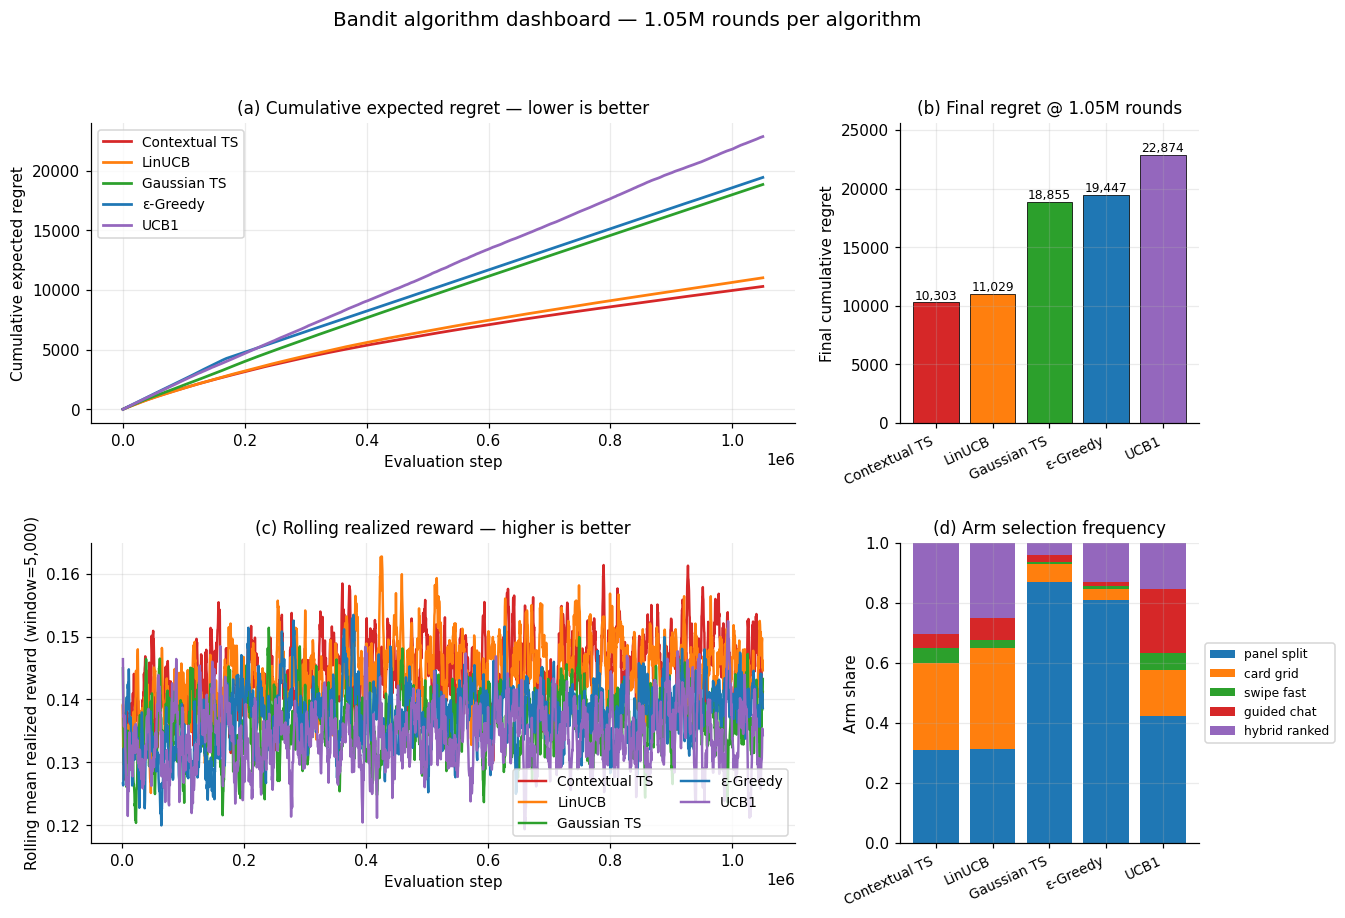

In [7]:
def subsample(x, n=2500):
    if len(x) <= n:
        return x
    idx = np.linspace(0, len(x) - 1, n).astype(int)
    return x.iloc[idx] if hasattr(x, 'iloc') else x[idx]

fig = plt.figure(figsize=(13, 8.5))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# (a) Cumulative expected regret — use evaluation step order
ax = fig.add_subplot(gs[0, 0:2])
for algo in ALGO_ORDER:
    sub = df[df['algo_name'] == algo].reset_index(drop=True)
    step = pd.Series(np.arange(len(sub)))
    ax.plot(subsample(step), subsample(sub['cumulative_expected_regret']),
            label=NICE_NAME[algo], color=PALETTE[algo], linewidth=1.8)
ax.set_xlabel('Evaluation step')
ax.set_ylabel('Cumulative expected regret')
ax.set_title('(a) Cumulative expected regret — lower is better')
ax.legend(loc='upper left', fontsize=9)

# (b) Final regret bars
ax = fig.add_subplot(gs[0, 2])
final_regret = [algo_summary.loc[algo_summary['algo_name'] == a,
                                  'final_cumulative_expected_regret'].iloc[0]
                for a in ALGO_ORDER]
colors = [PALETTE[a] for a in ALGO_ORDER]
bars = ax.bar(range(len(ALGO_ORDER)), final_regret,
              color=colors, edgecolor='black', linewidth=0.5)
for b, v in zip(bars, final_regret):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:,.0f}',
            ha='center', va='bottom', fontsize=8)
ax.set_xticks(range(len(ALGO_ORDER)))
ax.set_xticklabels([NICE_NAME[a] for a in ALGO_ORDER],
                    rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Final cumulative regret')
ax.set_title('(b) Final regret @ 1.05M rounds')
ax.set_ylim(0, max(final_regret) * 1.12)

# (c) Rolling reward
ax = fig.add_subplot(gs[1, 0:2])
window = 5000
for algo in ALGO_ORDER:
    sub = df[df['algo_name'] == algo].reset_index(drop=True)
    roll = sub['reward_realized'].rolling(window, min_periods=window // 5).mean()
    step = pd.Series(np.arange(len(sub)))
    ax.plot(subsample(step), subsample(roll),
            label=NICE_NAME[algo], color=PALETTE[algo], linewidth=1.6)
ax.set_xlabel('Evaluation step')
ax.set_ylabel(f'Rolling mean realized reward (window={window:,})')
ax.set_title('(c) Rolling realized reward — higher is better')
ax.legend(loc='lower right', fontsize=9, ncol=2)

# (d) Arm selection frequency
ax = fig.add_subplot(gs[1, 2])
arm_shares = (arm_freq.pivot(index='algo_name', columns='arm_selected_name',
                              values='share')
              .reindex(index=ALGO_ORDER, columns=ARM_ORDER).fillna(0))
bottom = np.zeros(len(arm_shares))
for arm in ARM_ORDER:
    if arm not in arm_shares.columns:
        continue
    ax.bar(range(len(arm_shares)), arm_shares[arm], bottom=bottom,
           label=arm.replace('_', ' '), color=ARM_COLORS[arm])
    bottom += arm_shares[arm].values
ax.set_xticks(range(len(arm_shares)))
ax.set_xticklabels([NICE_NAME[a] for a in arm_shares.index],
                    rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Arm share')
ax.set_ylim(0, 1)
ax.set_title('(d) Arm selection frequency')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)

fig.suptitle('Bandit algorithm dashboard — 1.05M rounds per algorithm',
             fontsize=13, y=1.00)
fig.savefig(FIGS / '03_bandit_dashboard.png')
plt.show()

## 7. Figure 4 — Contextual advantage per session goal

Where do contextual methods actually win? Broken down per session-goal context so we can
see that the contextual win is not uniform — it concentrates in goals with sharp per-context
preferences (focused_search, casual_browse, broad_exploration) and almost vanishes in
panic_apply, where the world is easier and any exploration is wasteful.

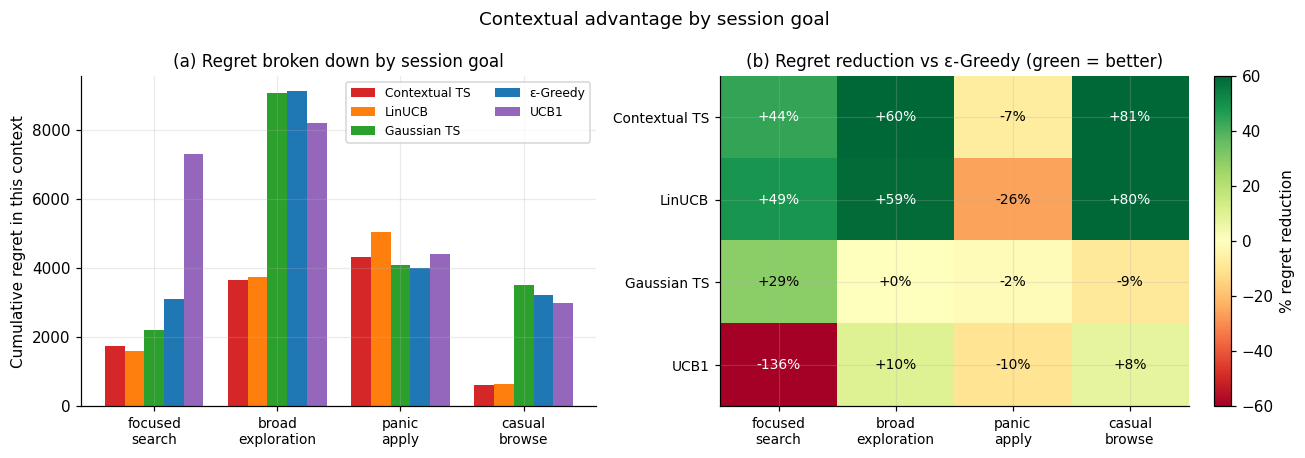


Per-session-goal cumulative regret:
session_goal    focused_search  broad_exploration  panic_apply  casual_browse
algo_name                                                                    
contextual_ts           1740.0             3640.0       4312.0          611.0
linucb                  1587.0             3744.0       5056.0          642.0
gaussian_ts             2194.0             9078.0       4077.0         3505.0
epsilon_greedy          3091.0             9119.0       4013.0         3224.0
ucb1                    7295.0             8194.0       4411.0         2974.0

Regret reduction vs ε-Greedy (%):
               focused_search  broad_exploration  panic_apply  casual_browse
contextual_ts            43.7               60.1         -7.5           81.0
linucb                   48.7               58.9        -26.0           80.1
gaussian_ts              29.0                0.5         -1.6           -8.7
ucb1                   -136.0               10.1         -9.9            7

In [8]:
per_sg = (df.groupby(['algo_name', 'session_goal'])['instant_expected_regret']
          .sum().unstack().reindex(index=ALGO_ORDER, columns=SESSION_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Left: grouped bar — regret per algo per session goal
ax = axes[0]
x = np.arange(len(SESSION_ORDER))
w = 0.16
for i, algo in enumerate(ALGO_ORDER):
    ax.bar(x + (i - 2) * w, per_sg.loc[algo].values, w,
           label=NICE_NAME[algo], color=PALETTE[algo])
ax.set_xticks(x)
ax.set_xticklabels([s.replace('_', '\n') for s in SESSION_ORDER], fontsize=9)
ax.set_ylabel('Cumulative regret in this context')
ax.set_title('(a) Regret broken down by session goal')
ax.legend(fontsize=8, ncol=2, loc='upper right')

# Right: % regret reduction vs ε-Greedy
baseline = 'epsilon_greedy'
advantage = pd.DataFrame(
    index=[a for a in ALGO_ORDER if a != baseline],
    columns=SESSION_ORDER, dtype=float
)
for algo in advantage.index:
    for sg in SESSION_ORDER:
        base_r = per_sg.loc[baseline, sg]
        algo_r = per_sg.loc[algo, sg]
        advantage.loc[algo, sg] = 100 * (base_r - algo_r) / base_r

ax = axes[1]
im = ax.imshow(advantage.astype(float).values, aspect='auto',
               cmap='RdYlGn', vmin=-60, vmax=60)
ax.set_xticks(range(len(SESSION_ORDER)))
ax.set_xticklabels([s.replace('_', '\n') for s in SESSION_ORDER], fontsize=9)
ax.set_yticks(range(len(advantage.index)))
ax.set_yticklabels([NICE_NAME[a] for a in advantage.index], fontsize=9)
for i in range(advantage.shape[0]):
    for j in range(advantage.shape[1]):
        v = float(advantage.iloc[i, j])
        ax.text(j, i, f'{v:+.0f}%', ha='center', va='center',
                color='white' if abs(v) > 30 else 'black', fontsize=9)
ax.set_title(f'(b) Regret reduction vs {NICE_NAME[baseline]} (green = better)')
fig.colorbar(im, ax=ax, fraction=0.04, label='% regret reduction')

fig.suptitle('Contextual advantage by session goal', fontsize=12)
fig.tight_layout()
fig.savefig(FIGS / '04_offline_bootstrap_replay.png')
plt.show()

print('\nPer-session-goal cumulative regret:')
print(per_sg.round(0).to_string())
print('\nRegret reduction vs ε-Greedy (%):')
print(advantage.round(1).to_string())

## 8. Figure 5 — Learned policy heatmaps

For each algorithm, the fraction of rounds it picks each arm within each session-goal
context. Contextual methods (left two) route arms differently per goal; non-contextual
methods (right three) collapse to one favored arm regardless of context.

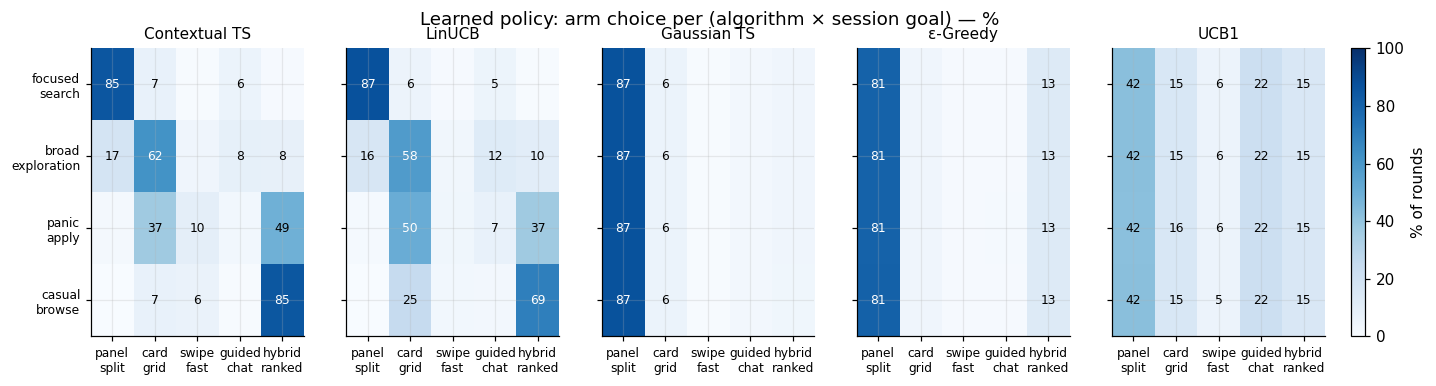

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3.4), sharey=True)

for ax, algo in zip(axes, ALGO_ORDER):
    sub = df[df['algo_name'] == algo]
    pol = (sub.groupby(['session_goal', 'arm_selected_name']).size()
           .unstack(fill_value=0))
    pol = pol.reindex(index=SESSION_ORDER,
                      columns=[a for a in ARM_ORDER if a in pol.columns])
    pol_pct = pol.div(pol.sum(axis=1), axis=0) * 100

    im = ax.imshow(pol_pct.values, aspect='auto', cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(len(pol_pct.columns)))
    ax.set_xticklabels([c.replace('_', '\n') for c in pol_pct.columns], fontsize=8)
    ax.set_yticks(range(len(pol_pct.index)))
    if ax is axes[0]:
        ax.set_yticklabels([s.replace('_', '\n') for s in pol_pct.index], fontsize=8)
    ax.set_title(NICE_NAME[algo], fontsize=10)
    for i in range(pol_pct.shape[0]):
        for j in range(pol_pct.shape[1]):
            v = pol_pct.iloc[i, j]
            if v > 5:
                ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                        color='white' if v > 50 else 'black', fontsize=8)

fig.suptitle('Learned policy: arm choice per (algorithm × session goal) — %',
             fontsize=12)
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label='% of rounds')
fig.savefig(FIGS / '05_behavioural_signals.png')
plt.show()

## 9. Figure 6 — Segment-level reward breakdown

Mean realized reward by company tier and by applicant cohort, per algorithm. Shows
where each algorithm's total reward comes from.

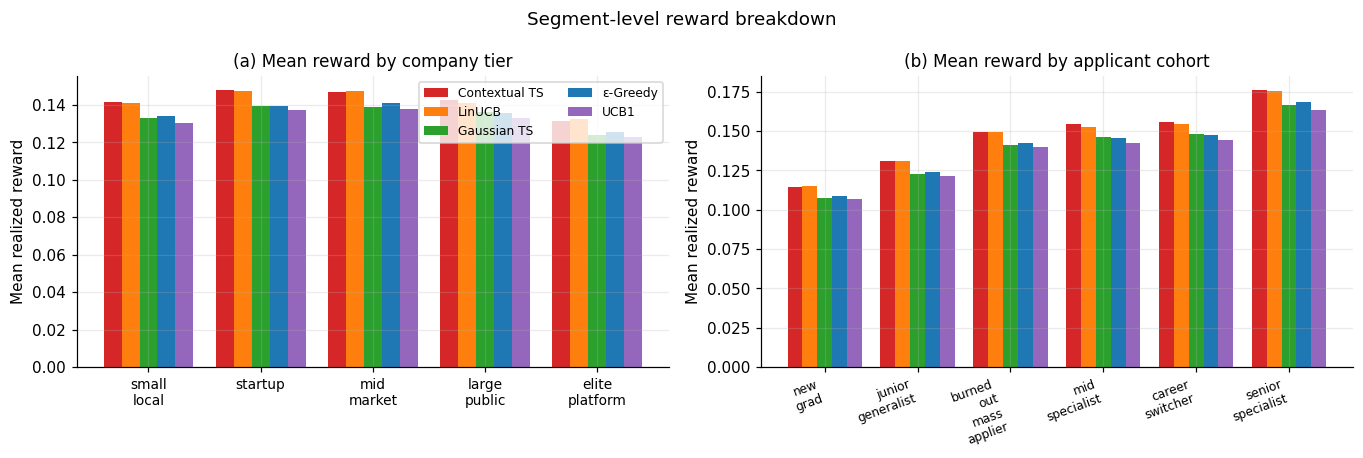

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

# (a) By company tier
tier_order = ['small_local', 'startup', 'mid_market', 'large_public', 'elite_platform']
tier_plot = (df.groupby(['algo_name', 'company_tier'])['reward_realized'].mean()
             .unstack()
             .reindex(index=ALGO_ORDER,
                      columns=[t for t in tier_order if t in df['company_tier'].unique()]))
ax = axes[0]
x = np.arange(len(tier_plot.columns))
w = 0.16
for i, algo in enumerate(ALGO_ORDER):
    ax.bar(x + (i - 2) * w, tier_plot.loc[algo].values, w,
           label=NICE_NAME[algo], color=PALETTE[algo])
ax.set_xticks(x)
ax.set_xticklabels([t.replace('_', '\n') for t in tier_plot.columns], fontsize=9)
ax.set_ylabel('Mean realized reward')
ax.set_title('(a) Mean reward by company tier')
ax.legend(fontsize=8, ncol=2)

# (b) By applicant cohort
ax = axes[1]
cohorts_sorted = (df.groupby('applicant_cohort')['reward_realized']
                  .mean().sort_values().index.tolist())
cohort_plot = (df.groupby(['algo_name', 'applicant_cohort'])['reward_realized'].mean()
               .unstack()
               .reindex(index=ALGO_ORDER, columns=cohorts_sorted))
x = np.arange(len(cohort_plot.columns))
for i, algo in enumerate(ALGO_ORDER):
    ax.bar(x + (i - 2) * w, cohort_plot.loc[algo].values, w,
           label=NICE_NAME[algo], color=PALETTE[algo])
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '\n') for c in cohort_plot.columns],
                    fontsize=8, rotation=20, ha='right')
ax.set_ylabel('Mean realized reward')
ax.set_title('(b) Mean reward by applicant cohort')

fig.suptitle('Segment-level reward breakdown', fontsize=12)
fig.tight_layout()
fig.savefig(FIGS / '06_hyperparameter_and_ablation.png')
plt.show()

## 10. Figure 7 — Session-goal routing heatmap

Mean instantaneous regret per (algorithm × session-goal) cell. Darker red = worse.

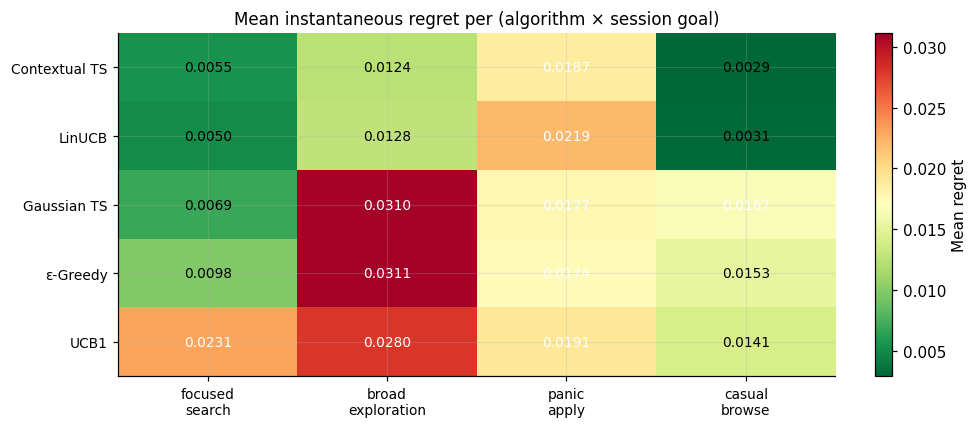


Mean regret per (algo × session goal):
session_goal    focused_search  broad_exploration  panic_apply  casual_browse
algo_name                                                                    
contextual_ts           0.0055             0.0124       0.0187         0.0029
linucb                  0.0050             0.0128       0.0219         0.0031
gaussian_ts             0.0069             0.0310       0.0177         0.0167
epsilon_greedy          0.0098             0.0311       0.0174         0.0153
ucb1                    0.0231             0.0280       0.0191         0.0141


In [11]:
mr = (df.groupby(['algo_name', 'session_goal'])['instant_expected_regret']
      .mean().unstack().reindex(index=ALGO_ORDER, columns=SESSION_ORDER))

fig, ax = plt.subplots(figsize=(9, 4.0))
im = ax.imshow(mr.values, aspect='auto', cmap='RdYlGn_r')
ax.set_xticks(range(len(SESSION_ORDER)))
ax.set_xticklabels([s.replace('_', '\n') for s in SESSION_ORDER], fontsize=9)
ax.set_yticks(range(len(ALGO_ORDER)))
ax.set_yticklabels([NICE_NAME[a] for a in ALGO_ORDER], fontsize=9)
mean_mr = mr.values.mean()
for i in range(mr.shape[0]):
    for j in range(mr.shape[1]):
        v = mr.iloc[i, j]
        ax.text(j, i, f'{v:.4f}', ha='center', va='center', fontsize=9,
                color='white' if v > mean_mr else 'black')
ax.set_title('Mean instantaneous regret per (algorithm × session goal)')
fig.colorbar(im, ax=ax, fraction=0.04, label='Mean regret')
fig.tight_layout()
fig.savefig(FIGS / '07_session_goal_routing.png')
plt.show()

print('\nMean regret per (algo × session goal):')
print(mr.round(4).to_string())

## 11. Verification — numbers for the report

Copy these into the `.tex` directly. Every value here was computed, not hardcoded.

In [12]:
print('=' * 72)
print('FINAL REPORT NUMBERS (copy into main.tex)')
print('=' * 72)
print()
print(f"Rounds per algorithm:  {len(df) // df['algo_name'].nunique():,}")
print(f"Total algorithm-rounds: {len(df):,}")
print(f"Seed(s):               {sorted(df['seed'].unique().tolist())}")
print()
print('Per-algorithm summary:')
print()
print(policy_summary.to_string(index=False))
print()
print('Regret reduction vs ε-Greedy (best non-contextual):')
base = algo_summary.loc[algo_summary['algo_name'] == 'epsilon_greedy',
                         'final_cumulative_expected_regret'].iloc[0]
for algo in ['contextual_ts', 'linucb', 'gaussian_ts', 'ucb1']:
    v = algo_summary.loc[algo_summary['algo_name'] == algo,
                          'final_cumulative_expected_regret'].iloc[0]
    sign = '−' if v < base else '+'
    print(f'  {NICE_NAME[algo]:16s}  {sign}{abs(100*(base-v)/base):5.1f}% regret')
print()
print('Oracle-best arm distribution (overall):')
oracle_shares_all = (one_algo['oracle_arm_name'].value_counts(normalize=True)
                     .reindex(ARM_ORDER).fillna(0))
for arm in ARM_ORDER:
    share = oracle_shares_all.get(arm, 0)
    print(f'  {arm:16s}  {100*share:5.1f}%')
print()
print('Arm selection frequency by algorithm:')
arm_matrix = (arm_freq.pivot(index='algo_name', columns='arm_selected_name',
                              values='share')
              .reindex(index=ALGO_ORDER, columns=ARM_ORDER).fillna(0) * 100)
print(arm_matrix.round(1).to_string())
print()
print('Files written:')
for p in sorted(FIGS.glob('*.png')):
    print(f'  {p.relative_to(REPO)}')
print(f'  {(FIGS / "policy_summary_table.csv").relative_to(REPO)}')

FINAL REPORT NUMBERS (copy into main.tex)

Rounds per algorithm:  1,050,000
Total algorithm-rounds: 5,250,000
Seed(s):               [4014]

Per-algorithm summary:

       policy  final_cum_reward  final_cum_regret  mean_reward  interview_rate  ignore_rate
Contextual TS         151722.81          10302.83       0.1445          0.1385       0.5918
       LinUCB         151293.08          11028.82       0.1441          0.1382       0.5918
  Gaussian TS         143242.55          18854.90       0.1364          0.1337       0.6030
     ε-Greedy         144075.39          19447.20       0.1372          0.1343       0.6047
         UCB1         140855.37          22874.04       0.1341          0.1304       0.6136

Regret reduction vs ε-Greedy (best non-contextual):
  Contextual TS     − 47.0% regret
  LinUCB            − 43.3% regret
  Gaussian TS       −  3.0% regret
  UCB1              + 17.6% regret

Oracle-best arm distribution (overall):
  panel_split        29.0%
  card_grid          2